In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3"
import numpy as np
import torch
import torch.functional as F
import torchvision
import os
#from utils.utils import rgb_loader,binary_loader
import timm
#from models.NGSNet import NGSNet,NGSNet_DL
from networks.VGSformer import VGSformer
import torchvision.transforms as transforms
import cv2
from PIL import Image


In [2]:

is_train = False
datasets_path = "./dataset/COD_dataset/{}/".format("train" if is_train else "test")


dataset = "CHAMELEON"
image_name = "animal-2"
x_type = "depth"
#/home/data1/ShiqiangShu/NGSNet/dataset/RGBD_dataset/train/COME/RGB/COME_Train_1.jpg
from urllib.request import urlopen
from PIL import Image
import timm

# img = Image.open('./fork/RGB.png')

# model = timm.create_model(
#     "swin_base_patch4_window12_384.ms_in22k_ft_in1k",
#     pretrained=True,
#     #features_only=True,
#     embed_dims = 96,
# )
# for n,m in model.named_modules():
#     print(n,m)

# model = model.eval()

# # get model specific transforms (normalization, resize)
# data_config = timm.data.resolve_model_data_config(model)
# _transforms = timm.data.create_transform(**data_config, is_training=False)

# output = model(_transforms(img).unsqueeze(0))  # unsqueeze single image into batch of 1

# top5_probabilities, top5_class_indices = torch.topk(output.softmax(dim=1) * 100, k=5)


# print(top5_class_indices)

RGB_path = "{}{}/RGB/{}.jpg".format(datasets_path,dataset,image_name)

X_path = "{}{}/{}/{}.png".format(datasets_path,dataset,x_type,image_name)
GT_path = "{}{}/GT/{}.png".format(datasets_path,dataset,image_name)
NAMLAB_path = "{}{}/namlab30/{}.png".format(datasets_path,dataset,image_name)
Bound_path = "{}{}/bound/{}.png".format(datasets_path,dataset,image_name)


In [3]:
from einops import rearrange
import torch.nn as nn
# feat = [torch.randn(4,768,24,24),torch.randn(4,384,48,48),torch.randn(4,192,96,96),torch.randn(4,96,192,192)]


# down_f1 = rearrange(feat[0],"b (c d1 d2) h w -> b c (h d1) (w d2)",d1=16,d2=16)

# conv_decoder = nn.Conv2d(3,1,15,2,padding=7)

# print(conv_decoder(down_f1).shape)

# part_f1 = rearrange(feat[0],"b (c d1 d2) h w -> b c (h d1) (w d2)",d1=2,d2=2)




In [4]:
from omegaconf import OmegaConf

test_model = "./log/2026-03-10-23:49:42-GSformer-segswin-base"

config = OmegaConf.load(os.path.join(test_model,'config.yaml'))


model = VGSformer(config)


state_dict = torch.load(test_model+"/ckpt/Best_mae_test.pth",map_location="cpu")

model_dict = {}

for k,v in state_dict.items():
    if k.startswith('module'):
        model_dict[k[7:]] = v
    else:
        model_dict[k] = v

model.load_state_dict(model_dict)
model = model.eval()
model = model.cuda()

# data_config = timm.data.resolve_model_data_config(model.encoderR)



#print(data_config)
IMG_SIZE = 384#data_config['input_size'][2]#TIMMGSformer().encoderR.

#transforms = timm.data.create_transform(**data_config, is_training=False)


{'TYPE': 'segswin', 'NAME': 'swin_base_patch4_window12_384_22kto1k_finetune', 'DROP_PATH_RATE': 0.2, 'DROP_RATE': 0.0, 'SWIN': {'PATCH_SIZE': 4, 'MLP_RATIO': 4, 'QKV_BIAS': True, 'QK_SCALE': None, 'PATCH_NORM': True, 'IN_CHANS': 3, 'EMBED_DIM': 128, 'DEPTHS': [2, 2, 18, 2], 'NUM_HEADS': [4, 8, 16, 32], 'WINDOW_SIZE': 12}, 'CKPT_NAME': 'segswin/swin_base_patch4_window12_384_22kto1k.pth'}
Pretrained weights found at ./pretrained/ckpts/segswin/swin_base_patch4_window12_384_22kto1k.pth and loaded with msg: _IncompatibleKeys(missing_keys=['norm0.weight', 'norm0.bias', 'norm1.weight', 'norm1.bias', 'norm2.weight', 'norm2.bias', 'norm3.weight', 'norm3.bias'], unexpected_keys=['norm.weight', 'norm.bias', 'head.weight', 'head.bias', 'layers.0.blocks.1.attn_mask', 'layers.1.blocks.1.attn_mask', 'layers.2.blocks.1.attn_mask', 'layers.2.blocks.3.attn_mask', 'layers.2.blocks.5.attn_mask', 'layers.2.blocks.7.attn_mask', 'layers.2.blocks.9.attn_mask', 'layers.2.blocks.11.attn_mask', 'layers.2.blocks.

In [5]:
rgb_transform = transforms.Compose([
    transforms.Resize(( IMG_SIZE,  IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
binary_transform = transforms.Compose([
    transforms.Resize(( IMG_SIZE,  IMG_SIZE)),
    transforms.ToTensor()])

gt_resize_transform = transforms.Compose([
    transforms.Resize(( IMG_SIZE,  IMG_SIZE),interpolation=transforms.InterpolationMode.NEAREST)
    ])

gt_transform = transforms.Compose([
    transforms.Resize(( IMG_SIZE//4,  IMG_SIZE//4),interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
    ])

resize_transform = transforms.Compose([
    transforms.Resize(( IMG_SIZE,  IMG_SIZE))
    ])

In [6]:
from pytorch_grad_cam.utils.image import show_cam_on_image



def rgb_loader(path):
    return Image.open(path).convert('RGB')

def binary_loader(path):
    return Image.open(path).convert('L')


RGB_image = rgb_loader(RGB_path)

H,W = RGB_image.size

#X_image = rgb_loader(X_path)


rgb_tensor = rgb_transform(RGB_image).unsqueeze(0).cuda()
#x_tensor = binary_transform(binary_loader(X_path)).unsqueeze(0).cuda()
gt_tensor = gt_transform(binary_loader(GT_path)).unsqueeze(0).cuda()

output = model(rgb_tensor)

print(type(output[0]), output[0].shape)


<class 'torch.Tensor'> torch.Size([1, 1, 384, 384])


In [7]:
save_path = "./asset/"
if not os.path.exists(save_path):
    os.makedirs(save_path,exist_ok=True)
    os.makedirs(save_path+'cam',exist_ok=True)
GT_image = binary_loader(GT_path)
bound_image = binary_loader(Bound_path)
#texture_image = binary_loader(NAMLAB_path)

resize_transform(RGB_image).save(save_path+"RGB.png")
#resize_transform(X_image).save(save_path+"X.png")
resize_transform(GT_image).save(save_path+"GT.png")
#resize_transform(bound_image).save(save_path+"bound.png")
#resize_transform(texture_image).save(save_path+"texture.png")


In [8]:

# with torch.no_grad():

#     s1,_,_,_,edge_sod,edge_rgb,edge_depth = model(rgb_tensor)    
#     print(s1.shape)#,s2.shape,s3.shape,s4.shape)


# cv2.imwrite("bound.png",(torch.sigmoid(edge_rgb).squeeze(0).squeeze(0).detach().cpu().numpy()*255).astype(np.uint8))


In [9]:
import torch.nn as nn
class RGBDSegmentationModelOutputWrapper(nn.Module):
    def __init__(self, model): 
        super(RGBDSegmentationModelOutputWrapper, self).__init__()
        self.model = model
        self.grad_block = {
            "rgb":None,
            "depth":None
        }

        
    def forward(self, rgb):
        

        y = self.model(rgb)
        return torch.cat((1-y[0],y[0]),dim=1)

    def set_block(self,rgb:torch.Tensor=None,depth:torch.Tensor=None):
        self.grad_block.update({"rgb":rgb,"depth":depth})
        

wrapper_model = RGBDSegmentationModelOutputWrapper(model)

output = wrapper_model(rgb_tensor)
print(output.shape)

torch.Size([1, 2, 384, 384])


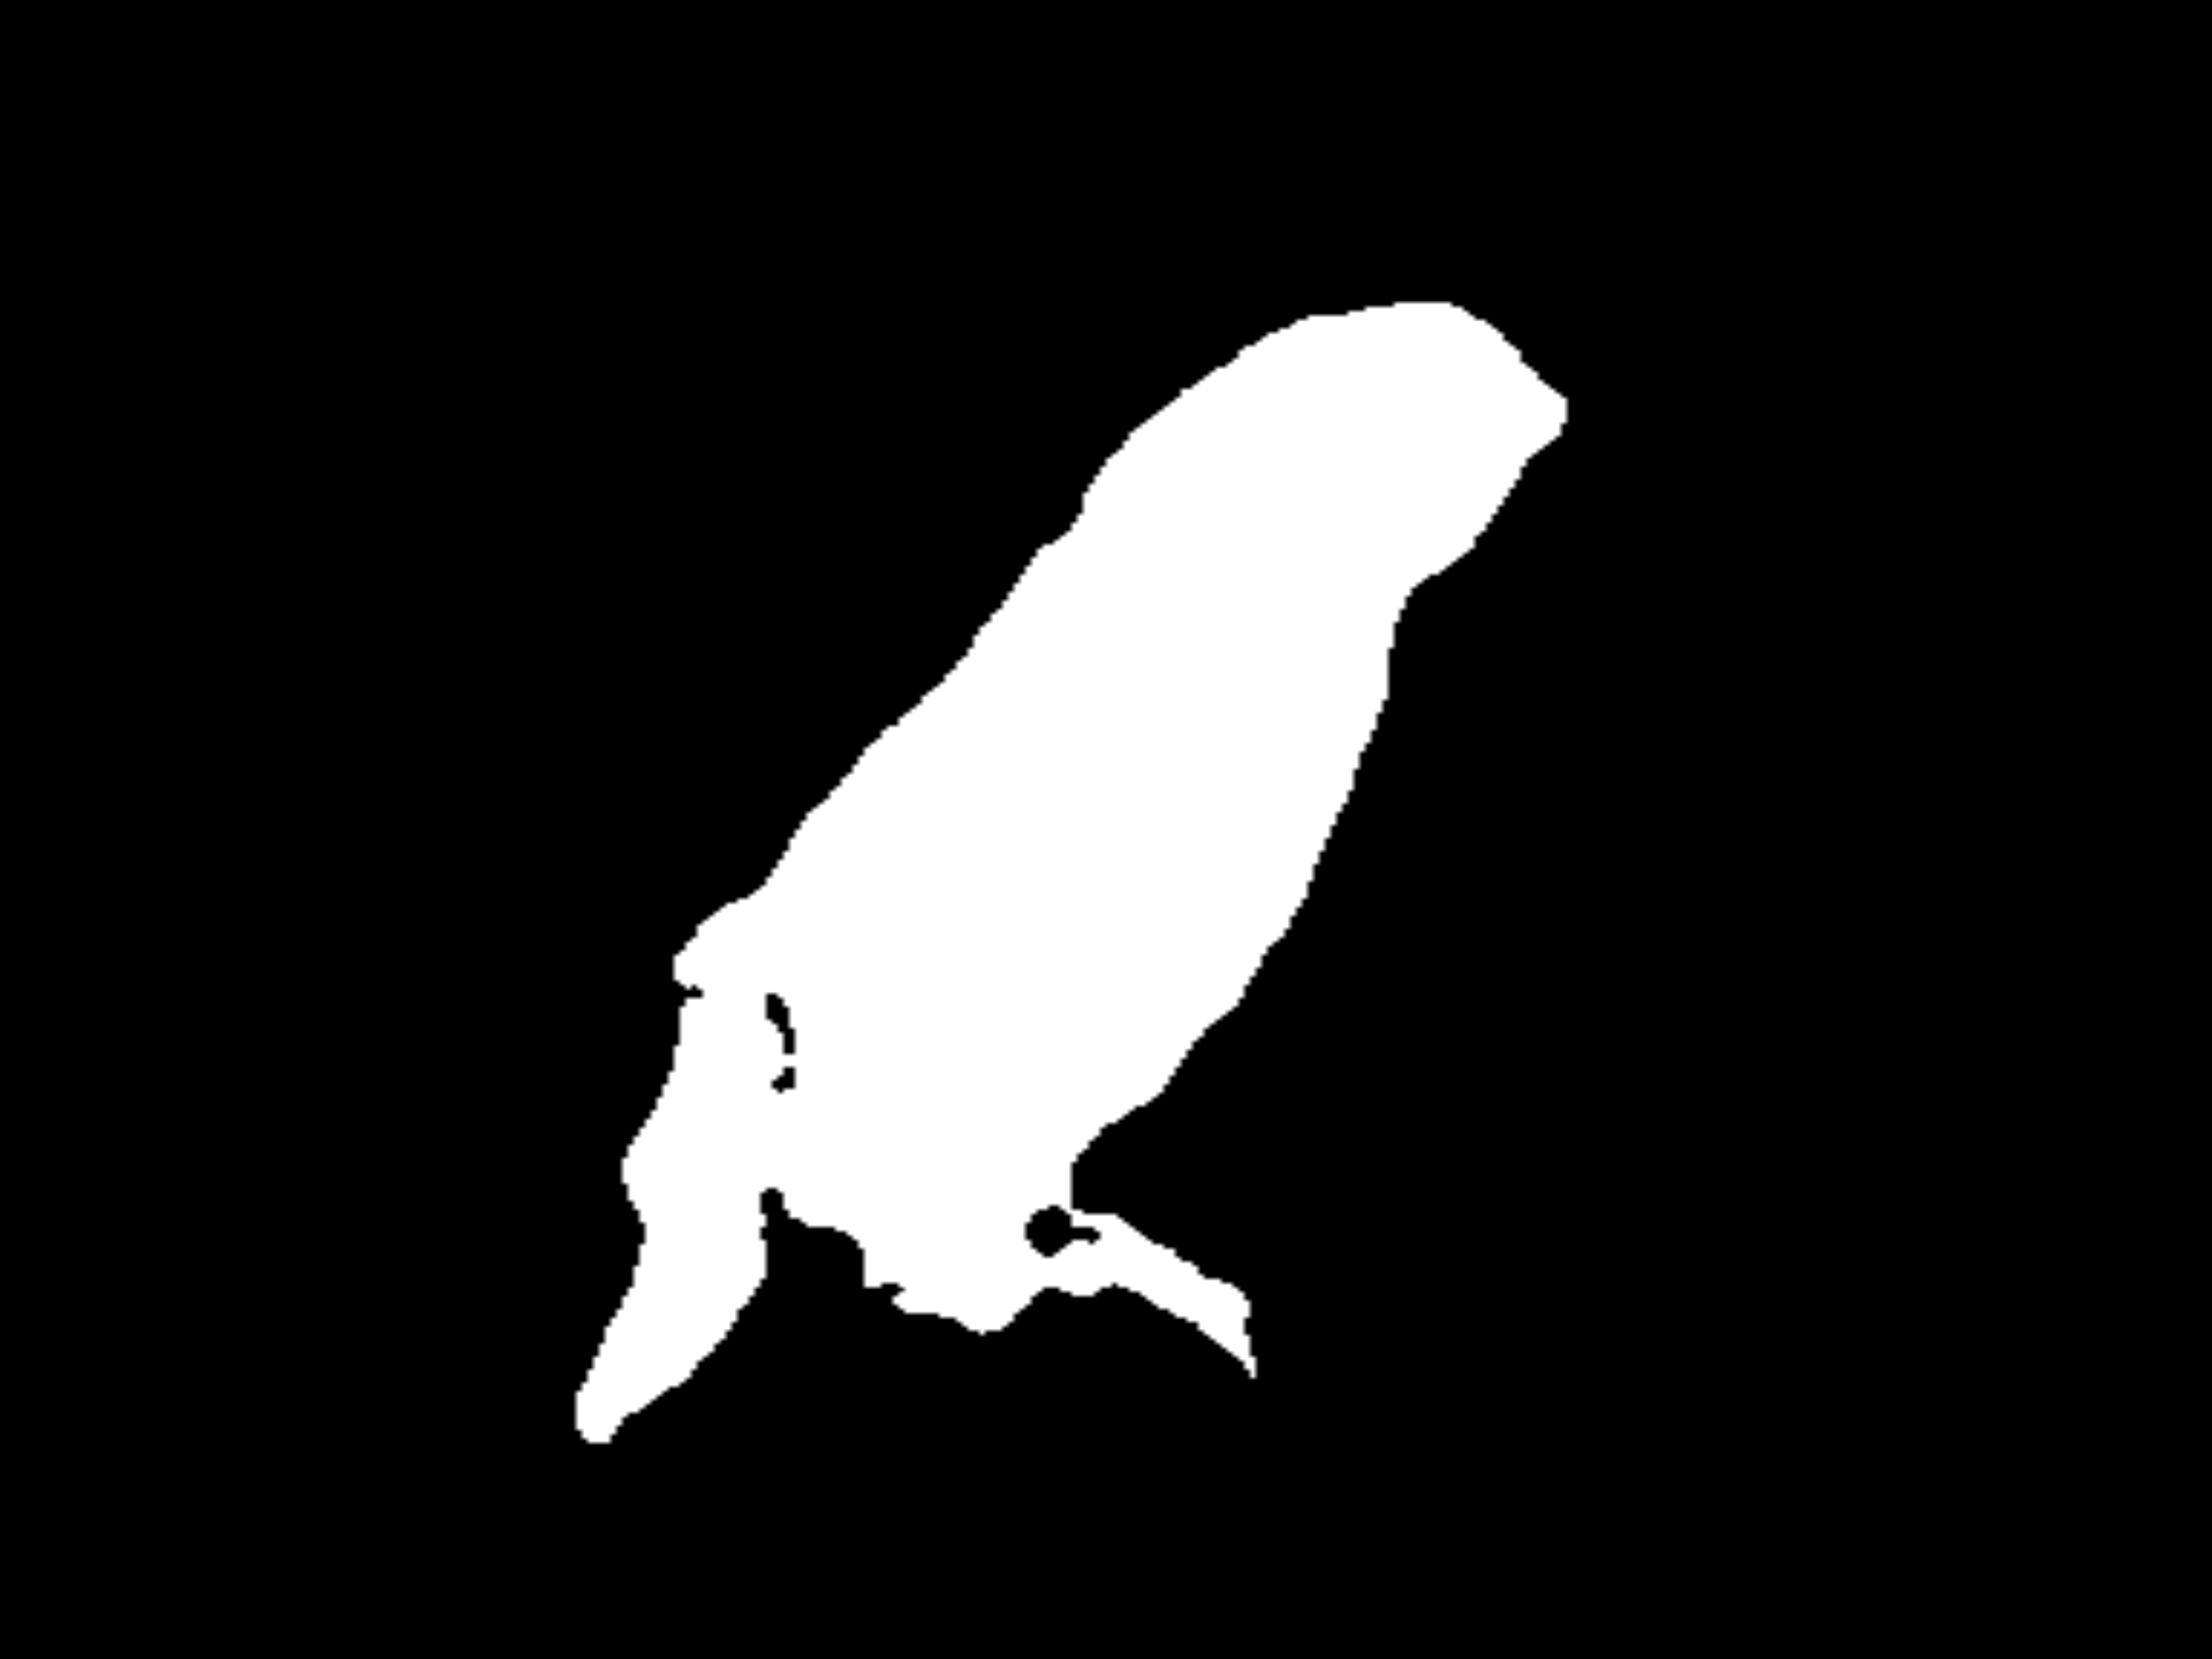

In [10]:
normalized_masks = torch.nn.functional.softmax(output, dim=1).cpu()

sem_classes = [
    '__background__', '__salient__'
]
sem_class_to_idx = {cls: idx for (idx, cls) in enumerate(sem_classes)}

category = sem_class_to_idx["__salient__"]

mask = normalized_masks[0, :, :, :].argmax(axis=0).detach().cpu().numpy()

mask_uint8 = 255 * np.uint8(mask == category)
mask_float = np.float32(mask == category)

mask_uint8 = cv2.resize(np.repeat(mask_uint8[:, :, None], 3, axis=-1),(H,W))

both_images = np.hstack((np.array(RGB_image),mask_uint8 ))
Image.fromarray(both_images)
Image.fromarray(mask_uint8)

In [11]:
import cv2
import numpy as np
def apply_pcolor_on_image(img: np.ndarray,mask: np.ndarray,colormap: int = cv2.COLORMAP_JET) -> np.ndarray:
    """
    img: cv2.imread得到的np.ndarray
    mask: [0-1]浮点数组成的矩阵,
    colormap:伪彩色色条选择
    """
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), colormap) #将cam的结果转成伪彩色图片
    cam = np.float32(heatmap)/255 + img/255
    cam = cam / np.max(cam)
    return np.uint8(255*cam)

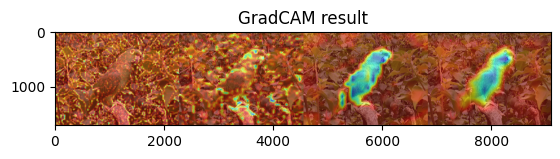

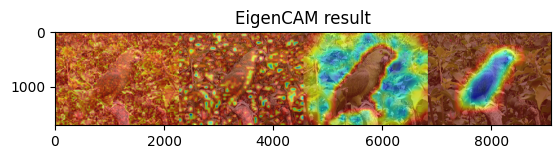

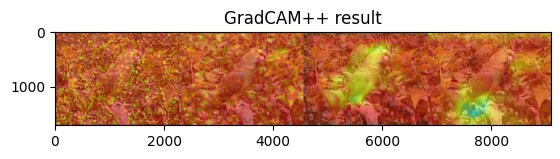

100%|██████████| 16/16 [00:07<00:00,  2.28it/s]


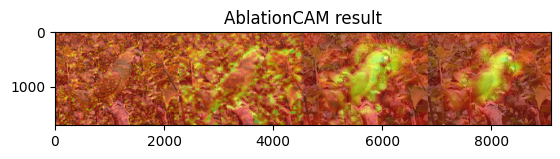

100%|██████████| 32/32 [00:07<00:00,  4.42it/s]


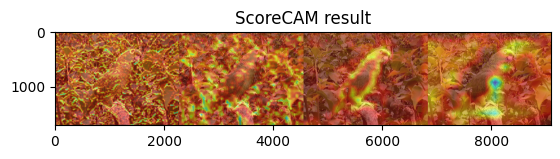

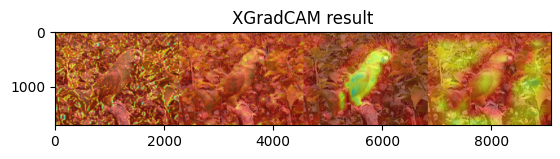

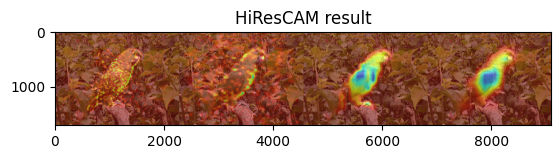

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import os # 新增：引入 os 模块用于创建文件夹
import cv2
import torch
import numpy as np
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM,GradCAMPlusPlus,AblationCAM,ScoreCAM,EigenCAM,XGradCAM,HiResCAM

cam_types = {
        "GradCAM":GradCAM,
        "EigenCAM":EigenCAM,
        "GradCAM++":GradCAMPlusPlus,
        "AblationCAM":AblationCAM,
        "ScoreCAM":ScoreCAM,
        "XGradCAM":XGradCAM,
        "HiResCAM":HiResCAM,
    }

class SemanticSegmentationTarget:
    def __init__(self, category, mask):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if torch.cuda.is_available():
            self.mask = self.mask.cuda()
        
    def __call__(self, model_output):
        return (model_output[self.category, :, : ] * self.mask).sum()

rgb_img = cv2.resize(np.float32(RGB_image) / 255,(IMG_SIZE,IMG_SIZE))

target_layers = [wrapper_model.model.aspf_dec1.conv1.bn,wrapper_model.model.aspf_dec2.conv1.bn,wrapper_model.model.aspf_dec3.conv1.bn,wrapper_model.model.aspf_dec4.conv1.bn]
targets = [SemanticSegmentationTarget(category, mask_float)]
cam_images = {}

for k,cam_func in cam_types.items():
    cam_images[k] = []
    
    # 新增：为当前的 CAM 方法（例如 AblationCAM）创建专门的子文件夹
    sub_folder_path = f"./asset/cam/{k}"
    os.makedirs(sub_folder_path, exist_ok=True)
    
    for i,target_layer in enumerate(target_layers):
        with cam_func(model=wrapper_model,
                    target_layers=[target_layer]) as cam:
            
            grayscale_cam = cam(input_tensor=rgb_tensor.cpu(),
                                targets=targets,aug_smooth=True)[0, :]
            tmp = cv2.resize(show_cam_on_image(rgb_img, grayscale_cam),(H,W))
            cam_images[k].append(tmp)
            
            # 修改：将单层结果图片保存到对应的子文件夹中，而不是全挤在外面
            cv2.imwrite(f"{sub_folder_path}/{i}_result.png", tmp)
            
    img = Image.fromarray(np.concatenate(cam_images[k], axis = 1))
    
    # 保持不变：汇总的大图依然放在 asset/cam 目录下，这里加了个 summary 方便区分（你也可以去掉）
    img.save(f"./asset/cam/{k}_summary_result.png")
    
    plt.imshow(img)
    plt.axis('on') # 关掉坐标轴为 off
    plt.title('{} result'.format(k)) # 图像题目
    plt.show()

In [13]:
#intro-sim and inter-sim of feature map
# import torch.nn.functional as nnF
# from einops import repeat
# def apply_sim():
#     return 

# def gen_mean():
#     pass

# def intro_sim(feature,mask):
#     """
#     feature:shape[C,H,W]
#     mask:shape[H,W]
#     """
#     C,H,W = feature.shape
#     mask = nnF.interpolate(feature,scale_factor=2,mode='nearest')
#     assert feature.shape[1:] == mask.shape[1:],"{}mismatch{}".format(feature.shape,mask.shape)
#     catos = torch.unique(mask)
#     cato_center = torch.zeros_like(feature,dtype=feature.dtype)
#     for cato in catos:
#         cato_center[repeat(mask==cato,"o h w -> (c o) h w",c=C)] = torch.mean(feature[repeat(mask==cato,"o h w -> (c o) h w",c=C)])
#     return nnF.cosine_similarity(feature, cato_center, dim=0)

# feat,_,_,_ = model.model.encoderR(rgb_tensor)
# feat = feat.permute(0,3,1,2).squeeze(0)
# mask = gt_tensor.squeeze(0)

    
# sim = torch.sigmoid(intro_sim(feat,mask)).detach().cpu().numpy()


# cv2.imwrite("sim.png",apply_pcolor_on_image(np.zeros((96,96,3)),sim))


In [14]:
#eval model on dataset
#open pkl to draw fig

#run test